🧺 Bagging (Bootstrap Aggregating)
----
📦 Sampling with replacement from the original dataset for each model.
Each model gets different but overlapping data.

✅ Helps reduce variance

🔁 With replacement

Some rows may repeat, some may be skipped.

-----------------------------

🧯 Pasting
----
🧪 Sampling without replacement from the dataset.
Each model gets different and non-overlapping data.

✅ Still adds diversity

🚫 No replacement

Each row is used once per model sample.

-----------------------------

🧩 Patching
----
🔀 Sampling both rows and columns from the dataset.
Used in methods like Random Forest (row + feature sampling).

✅ Increases randomness

📊 Row & feature subsets

Each model sees a different patch of the data matrix.

In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [2]:
df= sns.load_dataset('iris')

In [3]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [4]:
df = df.iloc[:,1:]

In [5]:
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,setosa
1,3.0,1.4,0.2,setosa
2,3.2,1.3,0.2,setosa
3,3.1,1.5,0.2,setosa
4,3.6,1.4,0.2,setosa


In [6]:
encoder = LabelEncoder()

In [7]:
df['species'] = encoder.fit_transform(df['species'])

In [8]:
df.head()

,sepal_width,petal_length,petal_width,species
0,3.5,1.4,0.2,0
1,3.0,1.4,0.2,0
2,3.2,1.3,0.2,0
3,3.1,1.5,0.2,0
4,3.6,1.4,0.2,0


In [9]:
df = df[df['species'] != 0][['sepal_width','petal_length','species']]

In [10]:
df.head()

,sepal_width,petal_length,species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

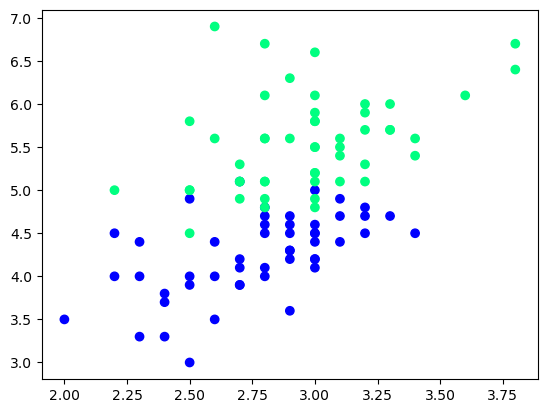

In [12]:
plt.scatter(df['sepal_width'],df['petal_length'],c=df['species'],cmap='winter')

In [13]:
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [14]:
df_train

,sepal_width,petal_length,species
133,2.8,5.1,2
121,2.8,4.9,2
80,2.4,3.8,1
60,2.0,3.5,1
50,3.2,4.7,1
112,3.0,5.5,2
87,2.3,4.4,1
130,2.8,6.1,2
63,2.9,4.7,1
131,3.8,6.4,2


In [15]:
df_val

,sepal_width,petal_length,species
110,3.2,5.1,2
57,2.4,3.3,1
123,2.7,4.9,2
116,3.0,5.5,2
89,2.5,4.0,1


In [16]:
df_test

,sepal_width,petal_length,species
101,2.7,5.1,2
64,2.9,3.6,1
132,2.8,5.6,2
53,2.3,4.0,1
84,3.0,4.5,1


In [17]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [18]:
y_test

array([2, 1, 2, 2, 1])

# Case 1 - Bagging

In [20]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
60,2.0,3.5,1
121,2.8,4.9,2
63,2.9,4.7,1
63,2.9,4.7,1
80,2.4,3.8,1
130,2.8,6.1,2
60,2.0,3.5,1
60,2.0,3.5,1


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [22]:
dt_bag1 = DecisionTreeClassifier()

In [23]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

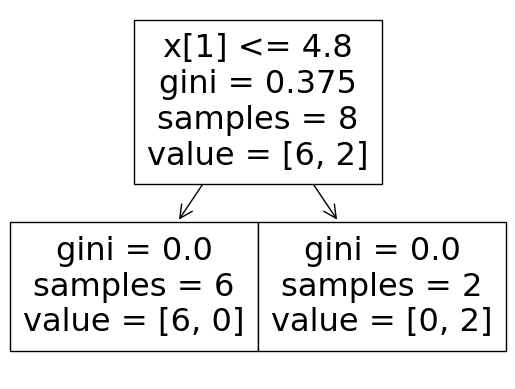

C:\Users\Vishal\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Vishal\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


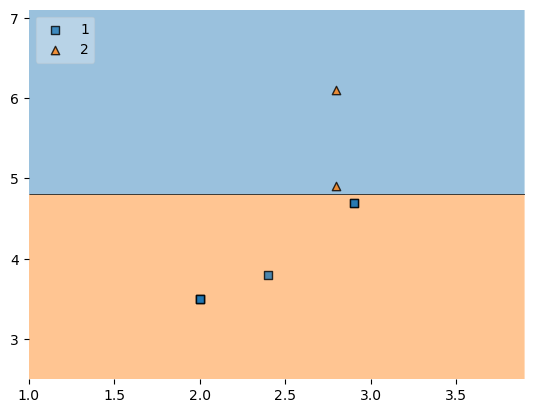

In [24]:
evaluate(dt_bag1,X,y)

In [25]:
df_bag = df_train.sample(8,replace=True)


X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
80,2.4,3.8,1
50,3.2,4.7,1
131,3.8,6.4,2
87,2.3,4.4,1
133,2.8,5.1,2
121,2.8,4.9,2
121,2.8,4.9,2
133,2.8,5.1,2


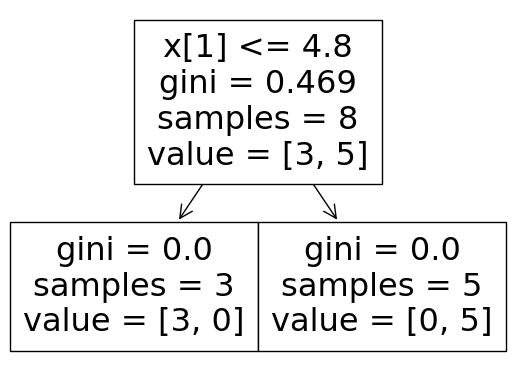

C:\Users\Vishal\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Vishal\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


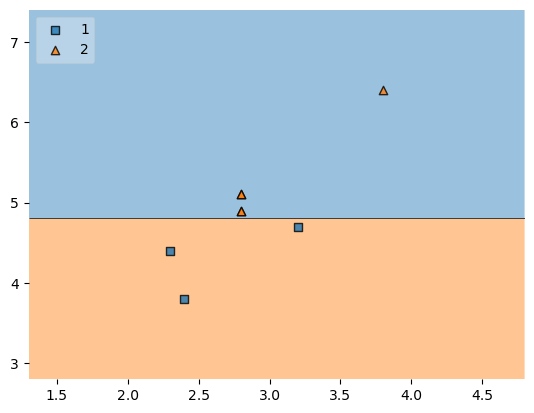

In [26]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [27]:
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal_width,petal_length,species
133,2.8,5.1,2
133,2.8,5.1,2
112,3.0,5.5,2
133,2.8,5.1,2
130,2.8,6.1,2
131,3.8,6.4,2
131,3.8,6.4,2
50,3.2,4.7,1


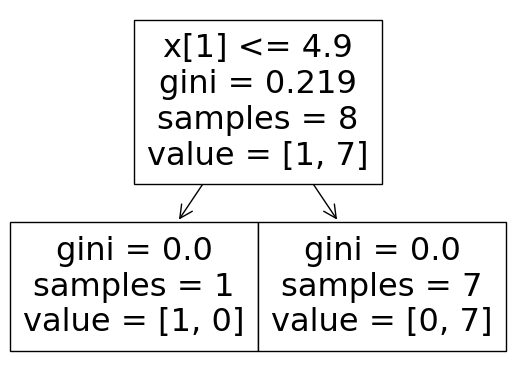

C:\Users\Vishal\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Vishal\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


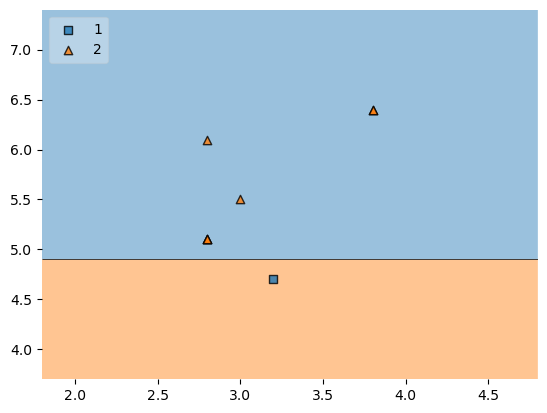

In [28]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

## Predict

In [29]:
df_test

,sepal_width,petal_length,species
101,2.7,5.1,2
64,2.9,3.6,1
132,2.8,5.6,2
53,2.3,4.0,1
84,3.0,4.5,1


In [31]:
print("Predictor 1",dt_bag1.predict(np.array([2.7,5.1]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.7,5.1]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.7,5.1]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


C:\Users\Vishal\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Vishal\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Vishal\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [32]:
df_train

,sepal_width,petal_length,species
133,2.8,5.1,2
121,2.8,4.9,2
80,2.4,3.8,1
60,2.0,3.5,1
50,3.2,4.7,1
112,3.0,5.5,2
87,2.3,4.4,1
130,2.8,6.1,2
63,2.9,4.7,1
131,3.8,6.4,2


In [36]:
df_train.sample(8)

,sepal_width,petal_length,species
133,2.8,5.1,2
60,2.0,3.5,1
80,2.4,3.8,1
87,2.3,4.4,1
131,3.8,6.4,2
130,2.8,6.1,2
63,2.9,4.7,1
50,3.2,4.7,1


# Random Subspaces

In [37]:
df1 = sns.load_dataset('iris')
df1 = df1.sample(10)

In [38]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
140,6.7,3.1,5.6,2.4,virginica
80,5.5,2.4,3.8,1.1,versicolor
139,6.9,3.1,5.4,2.1,virginica
37,4.9,3.6,1.4,0.1,setosa
91,6.1,3.0,4.6,1.4,versicolor
83,6.0,2.7,5.1,1.6,versicolor
27,5.2,3.5,1.5,0.2,setosa
105,7.6,3.0,6.6,2.1,virginica
16,5.4,3.9,1.3,0.4,setosa
10,5.4,3.7,1.5,0.2,setosa


In [41]:
df1.sample(2,replace=True,axis=1)

,petal_length,petal_length
140,5.6,5.6
80,3.8,3.8
139,5.4,5.4
37,1.4,1.4
91,4.6,4.6
83,5.1,5.1
27,1.5,1.5
105,6.6,6.6
16,1.3,1.3
10,1.5,1.5


# Random Patches

In [51]:
df1

,sepal_length,sepal_width,petal_length,petal_width,species
107,7.3,2.9,6.3,1.8,virginica
27,5.2,3.5,1.5,0.2,setosa
134,6.1,2.6,5.6,1.4,virginica
8,4.4,2.9,1.4,0.2,setosa
130,7.4,2.8,6.1,1.9,virginica
95,5.7,3.0,4.2,1.2,versicolor
145,6.7,3.0,5.2,2.3,virginica
106,4.9,2.5,4.5,1.7,virginica
55,5.7,2.8,4.5,1.3,versicolor
112,6.8,3.0,5.5,2.1,virginica


In [49]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,species,petal_length
83,versicolor,5.1
80,versicolor,3.8
91,versicolor,4.6
27,setosa,1.5
80,versicolor,3.8
139,virginica,5.4
140,virginica,5.6
27,setosa,1.5
